In [37]:
import os
import numpy as np
import glob
import shutil

import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense,BatchNormalization
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
import matplotlib.pyplot as plt

In [28]:
pip install fast_ml

Note: you may need to restart the kernel to use updated packages.


In [29]:
base_dir = "C:/Users/R00195490/Desktop/parag/kvasir-dataset-v2"

In [30]:
os.listdir("C:/Users/R00195490/Desktop/parag/kvasir-dataset-v2")

['dyed-resection-margins',
 'esophagitis',
 'normal-cecum',
 'normal-pylorus',
 'normal-z-line',
 'polyps',
 'test',
 'train',
 'ulcerative-colitis']

In [33]:
classes = ['dyed-lifted-polyps',
           'dyed-resection-margins',
           'esophagitis','normal-cecum',
           'normal-pylorus','normal-z-line',
           'polyps',
           'ulcerative-colitis']

In [34]:
#The dataset is split into train and test in such a way that 80% of the data as a training set 
#and 20% of the data as a test set
import os
import numpy as np
import shutil
import random

val_ratio = 0.15
test_ratio = 0.15
for cl in classes:
    
    img_path = os.path.join(base_dir, cl)
    images = glob.glob(img_path + '/*.jpg')
    print("{}: {} Images".format(cl, len(images)))
    
    
    train_list, test_list, val_list = images[:round(len(images)*0.7)], images[round(len(images)*0.7):round(len(images)*0.85)], images[round(len(images)*0.85):]

    for image in train_list:
        if not os.path.exists(os.path.join(base_dir, 'train', cl)):
            os.makedirs(os.path.join(base_dir, 'train', cl))
        shutil.copy(image, os.path.join(base_dir, 'train', cl))

    for image in test_list:
        if not os.path.exists(os.path.join(base_dir, 'test', cl)):
            os.makedirs(os.path.join(base_dir, 'test', cl))
        shutil.copy(image, os.path.join(base_dir, 'test', cl))
    
    for image in val_list:
        if not os.path.exists(os.path.join(base_dir, 'val', cl)):
            os.makedirs(os.path.join(base_dir, 'val', cl))
        shutil.copy(image, os.path.join(base_dir, 'val', cl))

dyed-lifted-polyps: 1000 Images
dyed-resection-margins: 1000 Images
esophagitis: 1000 Images
normal-cecum: 1000 Images
normal-pylorus: 1000 Images
normal-z-line: 1000 Images
polyps: 1000 Images
ulcerative-colitis: 1000 Images


In [35]:
IMAGE_SIZE = [224,224]

train_path = "C:/Users/R00195490/Desktop/parag/kvasir-dataset-v2/train"
Validation_path = "C:/Users/R00195490/Desktop/parag/kvasir-dataset-v2/val"

In [39]:
train_dataAugmentation = ImageDataGenerator(
      rescale=1./255
    )

test_dataAugmentation = ImageDataGenerator(rescale=1./255)

train_data_generator=train_dataAugmentation.flow_from_directory(train_path,
                                                 target_size=(200,200),
                                                 color_mode='rgb',
                                                 batch_size=32,
                                                 class_mode='categorical',
                                                 shuffle=True)

test_data_generator =test_dataAugmentation.flow_from_directory(Validation_path,
                                        target_size=(200,200),
                                       batch_size=50,
                                       class_mode='categorical')

Found 5600 images belonging to 8 classes.
Found 1200 images belonging to 8 classes.


In [45]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(200,200,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512,activation='relu'))
model.add(Dense(8,activation='softmax'))

model.compile(loss='categorical_crossentropy',
  optimizer='adam',metrics=['accuracy'])

In [51]:
history = model.fit_generator (steps_per_epoch=(train_data_generator.n//train_data_generator.batch_size),
                               generator=train_data_generator,
                               validation_data=test_data_generator,
                               validation_steps=test_data_generator.n//test_data_generator.batch_size,
                               epochs=5,
                               #callbacks = [EarlyStopping(monitor='val_loss'),
                               #ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)
)

Epoch 1/5
175/175 [==============================] - 103s 586ms/step - loss: 0.2997 - accuracy: 0.8727 - val_loss: 0.7550 - val_accuracy: 0.7342
Epoch 2/5
175/175 [==============================] - 105s 598ms/step - loss: 0.2437 - accuracy: 0.8996 - val_loss: 0.7875 - val_accuracy: 0.7267
Epoch 3/5
175/175 [==============================] - 103s 590ms/step - loss: 0.2110 - accuracy: 0.9145 - val_loss: 0.8252 - val_accuracy: 0.7150
Epoch 4/5
175/175 [==============================] - 104s 597ms/step - loss: 0.1595 - accuracy: 0.9350 - val_loss: 0.9904 - val_accuracy: 0.7258
Epoch 5/5
175/175 [==============================] - 102s 586ms/step - loss: 0.1256 - accuracy: 0.9523 - val_loss: 0.9483 - val_accuracy: 0.7200


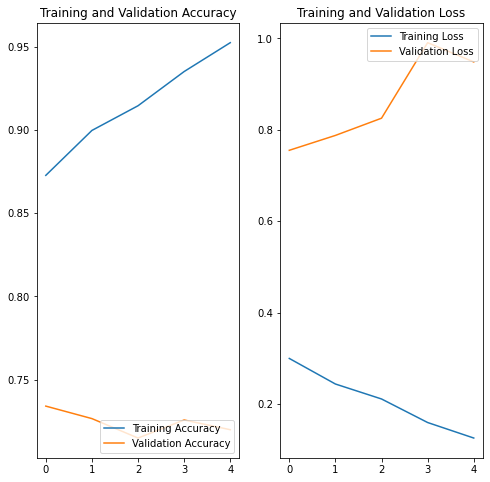

In [52]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [53]:
best_model = load_model(filepath='best_model.h5')
loss,acc=best_model.evaluate_generator(generator=test_data_generator,
steps=test_data_generator.n//test_data_generator.batch_size)

ResourceExhaustedError: failed to allocate memory [Op:AddV2]

In [54]:
print ('The best model Loss : ',loss)
print ('The best model Accuracy : ',acc)

The best model Loss :  [0.29970672726631165, 0.24374771118164062, 0.21101978421211243, 0.159502312541008, 0.12557250261306763]
The best model Accuracy :  [0.8726785778999329, 0.8996428847312927, 0.9144642949104309, 0.9350000023841858, 0.9523214101791382]
